# Yan et al. (2013) – Single-cell RNA-Seq profiling of human preimplantation embryos and embryonic stem cells

The original paper can be found here: https://www.nature.com/articles/nsmb.2660

__Abstract__: Measuring gene expression in individual cells is crucial for understanding the gene regulatory network controlling human embryonic development. Here we apply single-cell RNA sequencing (RNA-Seq) analysis to 124 individual cells from human preimplantation embryos and human embryonic stem cells (hESCs) at different passages. The number of maternally expressed genes detected in our data set is 22,687, including 8,701 long noncoding RNAs (lncRNAs), which represents a significant increase from 9,735 maternal genes detected previously by cDNA microarray. We discovered 2,733 novel lncRNAs, many of which are expressed in specific developmental stages. To address the long-standing question whether gene expression signatures of human epiblast (EPI) and in vitro hESCs are the same, we found that EPI cells and primary hESC outgrowth have dramatically different transcriptomes, with 1,498 genes showing differential expression between them. This work provides a comprehensive framework of the transcriptome landscapes of human early embryos and hESCs.

Yan et al. (2013) is an early SMART-seq study. They conduct a supervised, biology-label-driven analysis, they didn’t do mutual information clustering (as scMINER), they compared known groups (stages) and reported which genes differ.

They write "Here, using the single-cell RNA-Seq technique, we sequenced the transcriptome of human oocytes and early embryos at **seven** developmental stages [...]."

Another paper **SC3: consensus clustering of single-cell RNA-seq data** by Kiselev et al. (2017) uses the Yan et al. dataset to benchmark their clustering method SC3, which can be found here: https://www.nature.com/articles/nmeth.4236

They proceed as following:
- SC3 treats Yan as a small, gold-standard set with N = 90 cells, k = 7 clusters, and RPKM units (Fig. 1b in the paper above).
- After an internal gene filter, SC3 log-transforms the filtered matrix as M' = log_2(M + 1)
- They then proceed with their own analysis.

## 0. Imports & Set-Up:

In [53]:
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import pairwise_distances, adjusted_rand_score
from sklearn.preprocessing import FunctionTransformer

from umap import UMAP

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt

from carve import CARVE
from carve.config import ValidatorConfig


In [19]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Import & Process Data

In [20]:
X = pd.read_csv("../data/Yan/yan_log2p1_expr.csv.gz", index_col=0)  # genes x cells
obs = pd.read_csv("../data/Yan/yan_cell_meta.csv").set_index("cell_id")

adata = sc.AnnData(X.T)  # cells x genes
adata.obs = obs.loc[adata.obs_names].copy()
adata

AnnData object with n_obs × n_vars = 90 × 20214
    obs: 'label'

In [21]:
mat = adata.X
X = pd.DataFrame(mat.T, index=adata.var_names, columns=adata.obs_names)  # genes x cells
y = adata.obs['label'].values

X.shape, y.shape

((20214, 90), (90,))

In [22]:
print(f"np.unique(obs): {np.unique(obs)}")
print(f"len(np.unique(obs)): {len(np.unique(obs))}")

np.unique(obs): ['16cell' '2cell' '4cell' '8cell' 'blast' 'zygote']
len(np.unique(obs)): 6


SC3’s bundled (ann) uses a 90-cell data set with six developmental stages (no hESC, and blastocyst lineages collapsed).

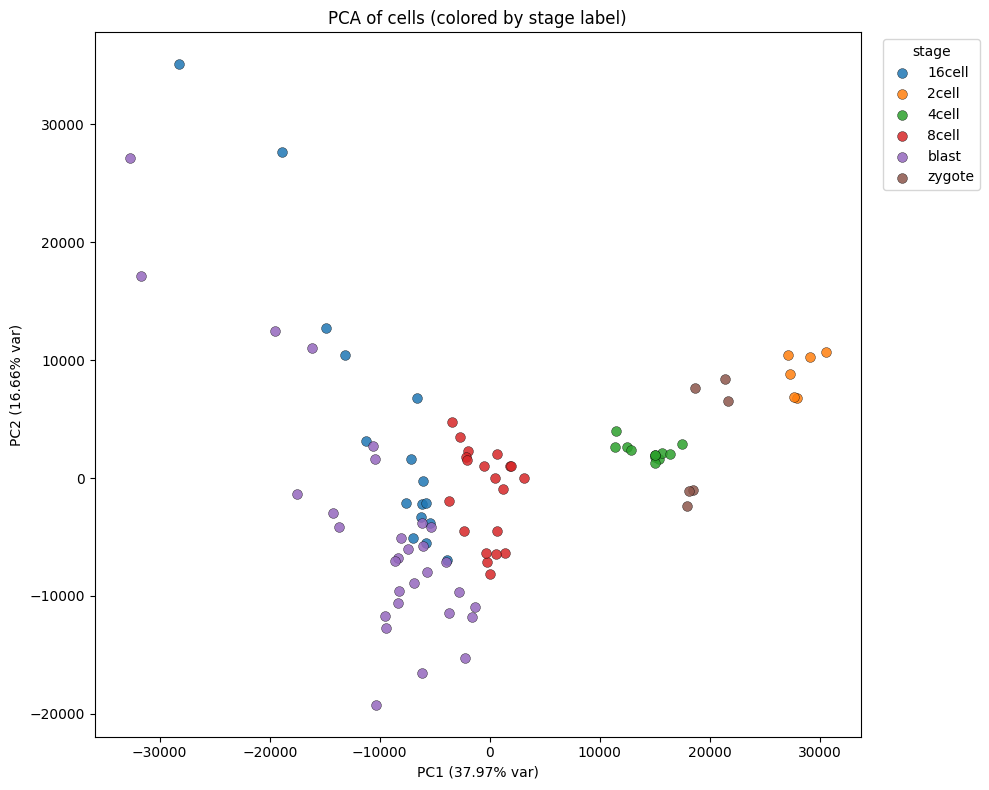

In [23]:
# PCA on cells (samples are columns of X) and scatter plot colored by y
pca = PCA(n_components=2)
pcs = pca.fit_transform(X.T)  # shape: (n_cells, 2)

pc_df = pd.DataFrame(pcs, index=X.columns, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Normalize and Select Highly-Variable Genes:

In [24]:
print(adata.obs.columns)

Index(['label'], dtype='object')


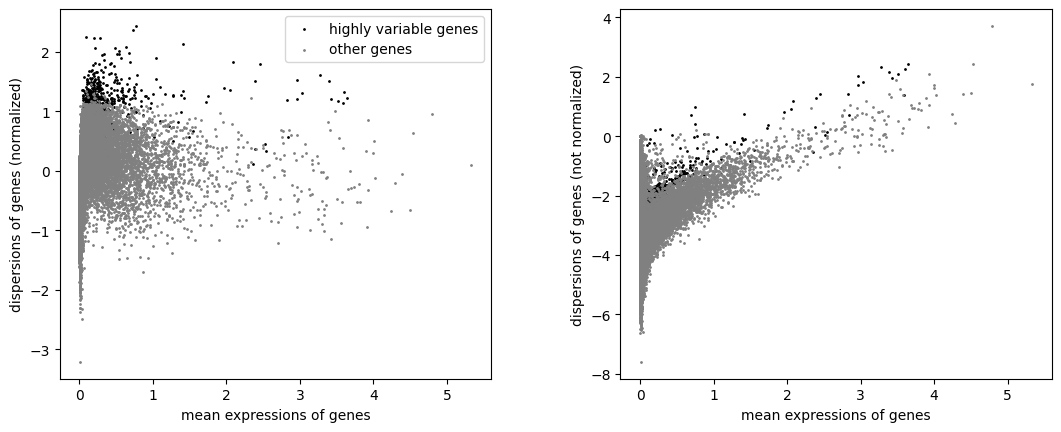

In [25]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="label", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [26]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [27]:
# Overwrite X and y using the (HVG-subset) adata
X = pd.DataFrame(adata.X.T, index=adata.var_names, columns=adata.obs_names)  # genes x cells
X = X.T
y = adata.obs['label'].values

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (90, 500)
y.shape: (90,)


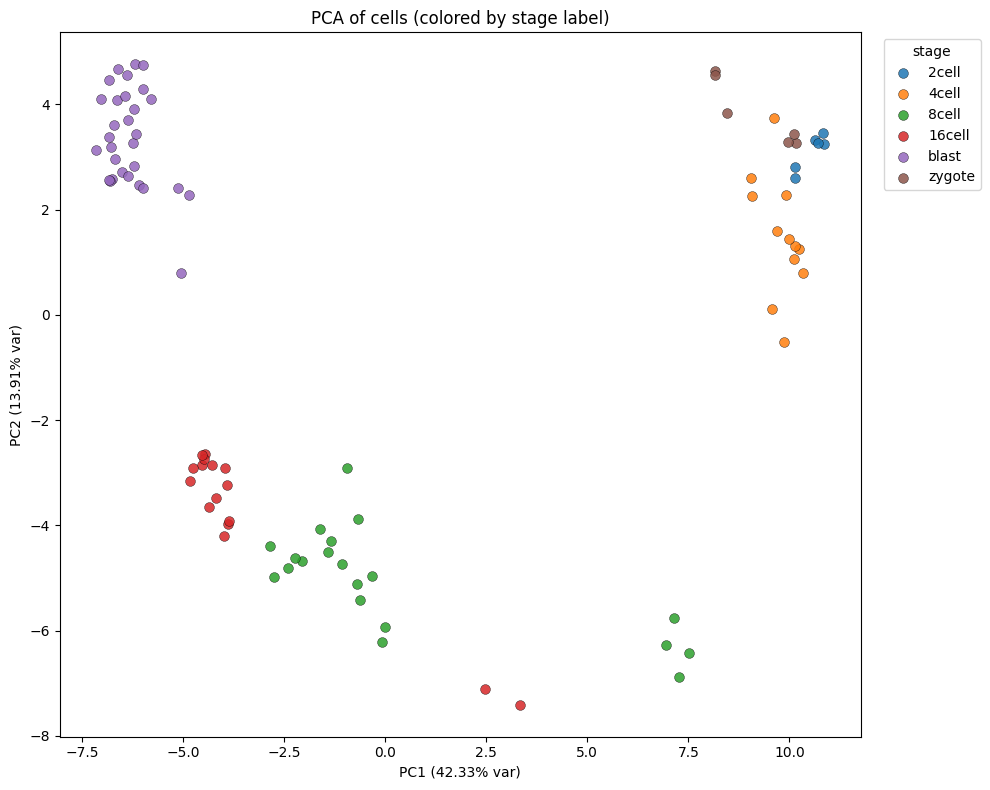

In [28]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

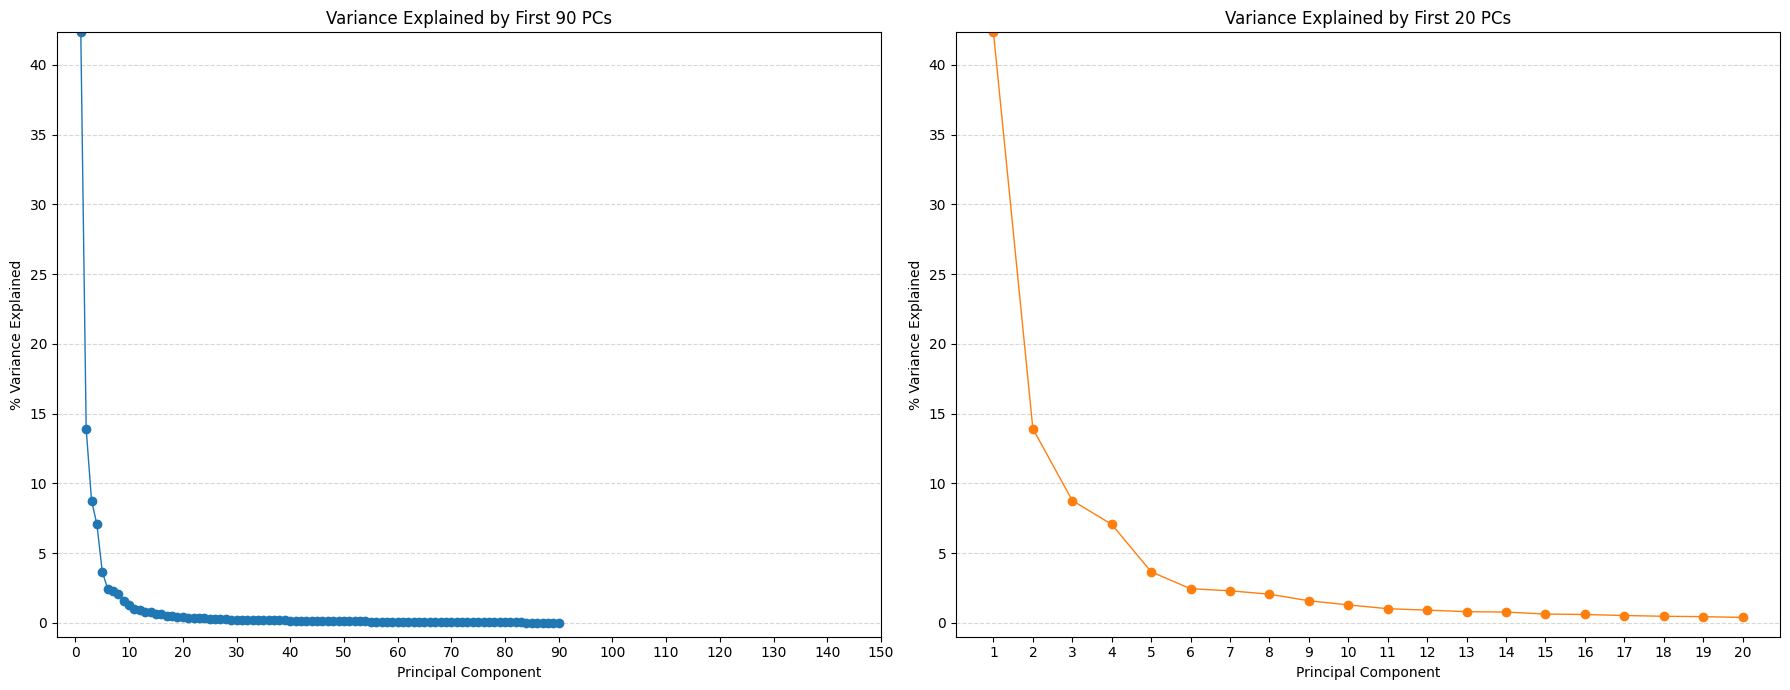

In [ ]:
pca = PCA(n_components=90)
pcs = pca.fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ymin = min(pca.explained_variance_ratio_[:90] * 100).min() - 1
ymax = max(pca.explained_variance_ratio_[:90] * 100).max()
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

ax[0].plot(np.arange(1, 91), pca.explained_variance_ratio_[:90] * 100, marker='o', linewidth=1)
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('% Variance Explained')
ax[0].set_title('Variance Explained by First 90 PCs')
ax[0].set_xticks(np.arange(0, 91, 10))
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

ax[1].plot(np.arange(1, 21), pca.explained_variance_ratio_[:20] * 100, marker='o', linewidth=1, color='tab:orange')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('% Variance Explained')
ax[1].set_title('Variance Explained by First 20 PCs')
ax[1].set_xticks(np.arange(1, 21, 1))
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
expl_var = pca.explained_variance_ratio_[:20] * 100
diffs = np.diff(expl_var)

drop_start = 5 - 1  # PC5 is index 4
drop_end = 10 - 1  # PC10 is index 9
drop_idx = np.argmin(diffs[drop_start:drop_end]) + drop_start

print(f"Largest drop between PC5 and PC10 is between PC{drop_idx+1} and PC{drop_idx+2}:")
print(f"Explained variance drops from {expl_var[drop_idx]:.2f}% to {expl_var[drop_idx+1]:.2f}% (Δ = {diffs[drop_idx]:.2f}%)")

Largest drop between PC5 and PC10 is between PC5 and PC6:
Explained variance drops from 3.65% to 2.44% (Δ = -1.21%)


In [31]:
explained_var_5 = pca.explained_variance_ratio_[:5].sum() * 100
print(f"Cumulative variance explained by the first 5 PCs: {explained_var_5:.2f}%")

Cumulative variance explained by the first 5 PCs: 75.71%


---

### Determine Pre-Processing Pipeline with CARVE:

In [32]:
id_norm = [
    (FunctionTransformer, {}), 
]

dr_options = [
    (PCA, {
        'n_components': [5]
    }),
    (TSNE, {
        'n_components': [2], 
        'perplexity': list(range(5, 30+1))
    }),
    (UMAP, {
        'n_components': [2], 
        'n_neighbors': list(range(5, 15+1)), 
        'min_dist': [0.1]
    }),
]

cfg = ValidatorConfig(
    X=X,
    K=10,
    B=100,
    norm_options=id_norm,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=True, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

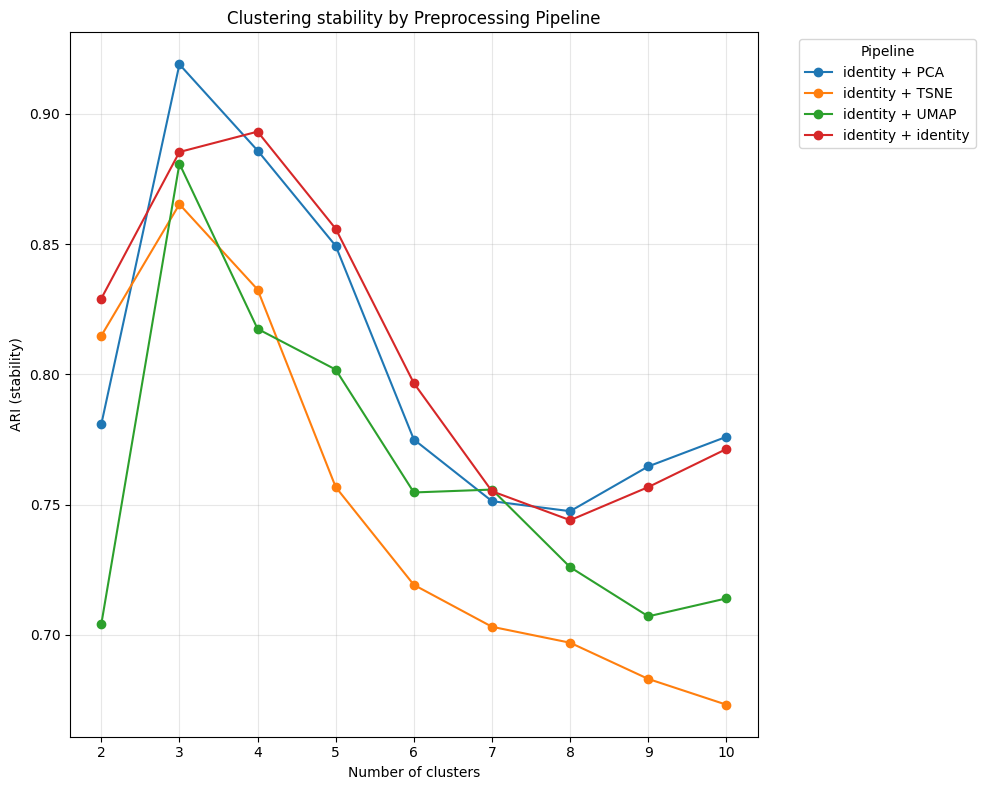

In [33]:
val.plot_preprocessing_results()

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



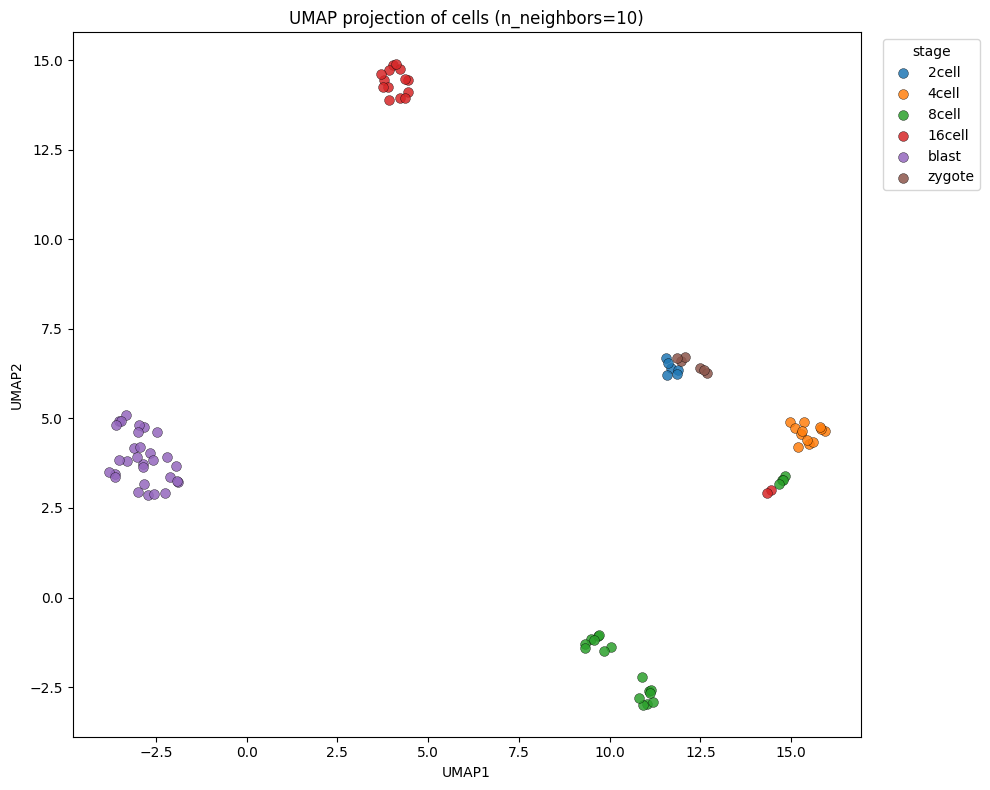

In [ ]:
umap = UMAP(n_components=2, n_neighbors=10, random_state=42)
X_umap = umap.fit_transform(X)

plt.figure(figsize=(10, 8))
labels = pd.Categorical(y).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = (y == lab)
    plt.scatter(X_umap[sel, 0], X_umap[sel, 1], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP projection of cells (n_neighbors=10)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Explore both UMAP and PCA:

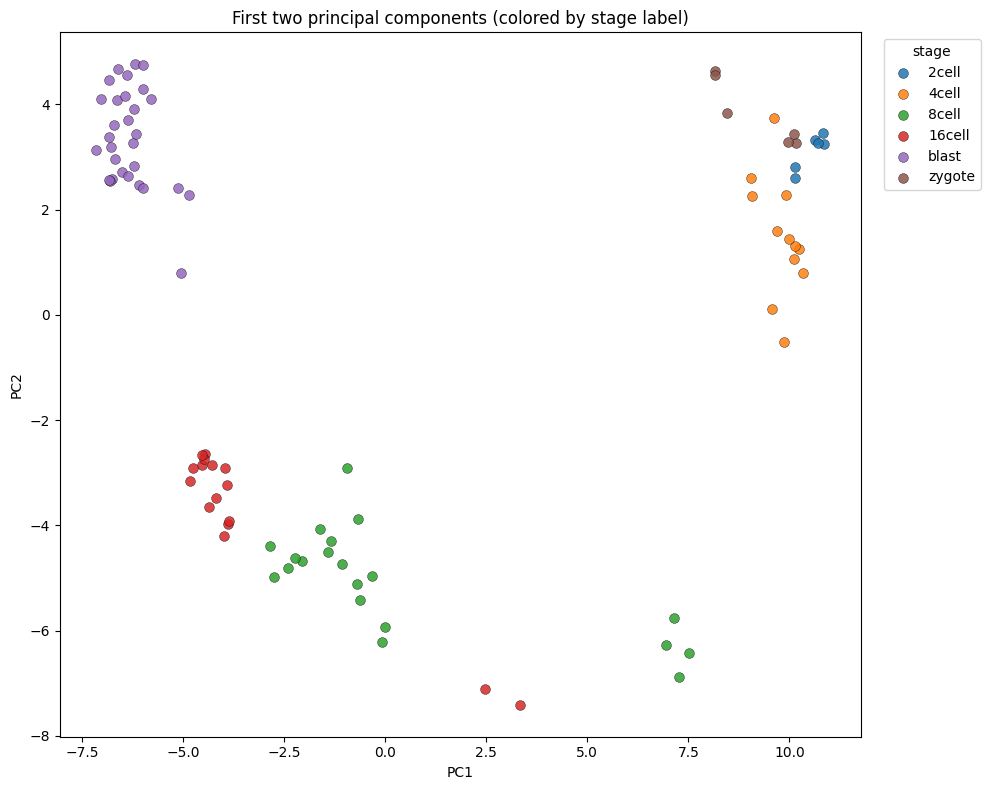

In [ ]:
pca = PCA(n_components=14)
X_pca = pca.fit_transform(X)

pc_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(y).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df['label'] == lab
    plt.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("First two principal components")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### Determine Optimal Clustering with CARVE:

PCA:

In [38]:
cfg = ValidatorConfig(
    X=X_pca,
    K=10,
    B=100,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

In [39]:
val.plot_results(measure='s', rule='1se')

In [40]:
val.plot_results(measure='g', rule='1se')

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_plotting.py:474: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



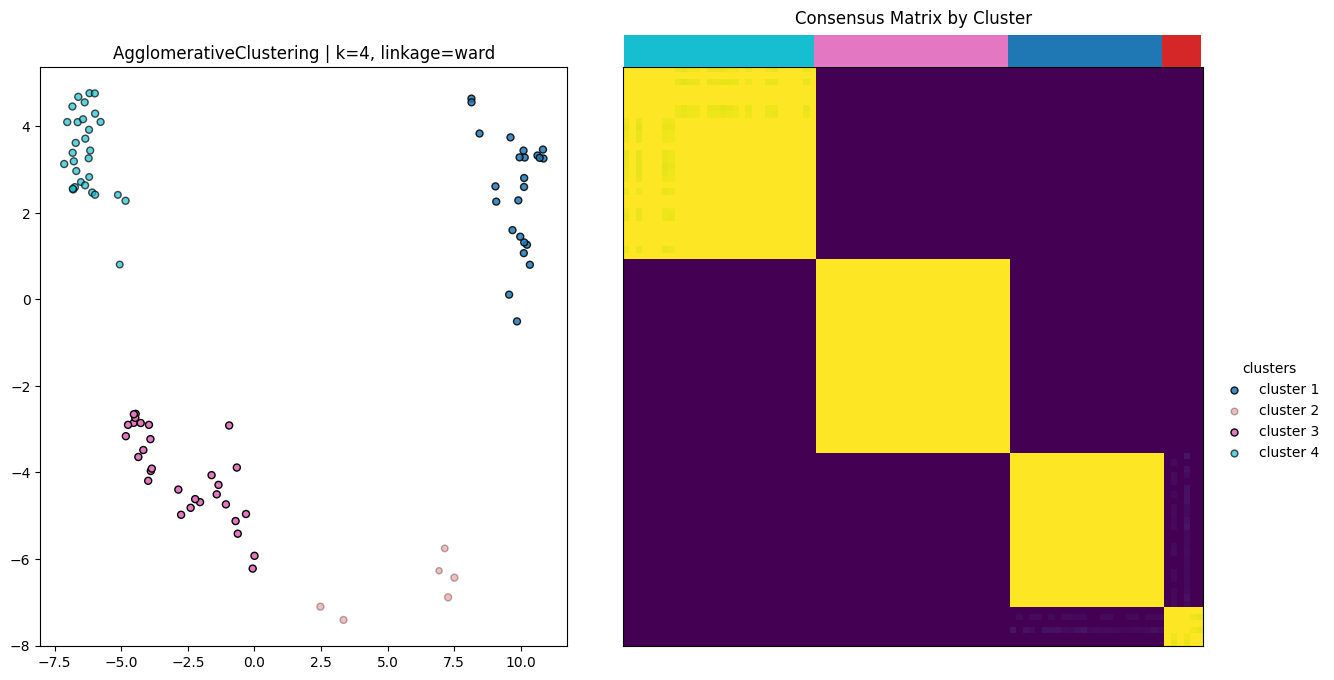

In [43]:
val.plot_consensus_clustering(measure='s', rule='1se', figsize=(15, 8))

In [44]:
val.plot_clustering(measure='s', rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAOEAAAAAAAAAAAAAAAAAAAP' ... 'rnQAPp7z801xoKJ9rvP+xRuB6F6+E/'),
                             'dtype': 'f8',
                             'shape': '6, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.3,
                         'size': {'bdata': '/O5jaTPVKkCo9Jebd+MRQINNmngyOyNA/O5jaTPVKkBJzNpn+xgqQBSYCrdO1ylA',
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'ce74607d-9f6b-4fde-947b-7a87091d481c',
              'x': {'bdata': '85BhW44MHkD84rio5L0bQAox9eDBmBxAwyqTuWEaHUC59iFtPdUDQICanBhByApA', 'dtype': 'f8'},
             

UMAP:

In [45]:
cfg = ValidatorConfig(
    X=X_umap,
    K=10,
    B=100,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

In [46]:
val.plot_results(measure='s', rule='1se')

In [47]:
val.plot_results(measure='g', rule='1se')

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_plotting.py:474: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



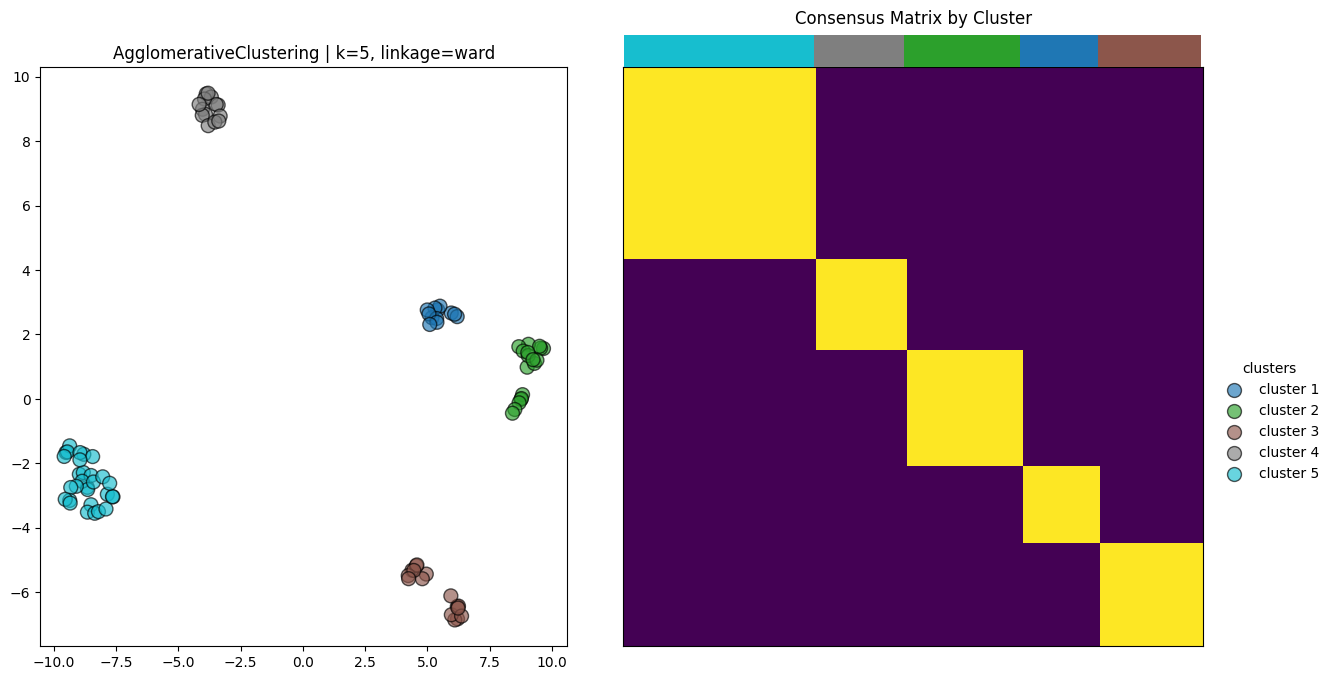

In [48]:
val.plot_consensus_clustering(measure='s', rule='1se', figsize=(15, 8))

In [52]:
val.plot_clustering(measure='s', rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAPEAAAAAAAAAAAAAAAAAAAP' ... 'AAAAAA8D+wUvr////vPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '16, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.65,
                         'size': {'bdata': ('AAAAAAAAJEAAAAAAAAAkQAAAAAAAAC' ... 'AAAAAkQAAAAAAAACRAAAAAAAAAJEA='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'ed2eabf8-b96d-492b-ab99-e5b258f4df8f',
              'x': {'bdata': ('cTyMQM2QnkDbe5lAL9iRQLePkkBtbI' ... 'BjwL5AS+nHQC8ivkDB5stAsWLHQA=='),
                 

In [55]:
agg = AgglomerativeClustering(n_clusters=len(y.categories), linkage='ward')
pred_labels = agg.fit_predict(X_umap)
ari = adjusted_rand_score(y, pred_labels)
print(f"ARI of AgglomerativeClustering (ward linkage) with true labels: {ari:.4f}")

ARI of AgglomerativeClustering (ward linkage) with true labels: 0.7917
